#  Rigid Rotor

$$
\hat{H} = -\frac{1}{2I}\,\frac{d^2}{d\theta^2} + V_{0} \sin^2\!\left(\tfrac{3\theta}{2}\right) \\
$$ 
$$
θ ∈ [0, 2π], V_{0} = 1, I = 20
$$

Part 1: (a) Write a program (e.g., in Python) to compute the eigenstates and eigenvalues of this
system in the basis of functions $\phi_n(\theta) = \frac{e^{i n \theta}}{\sqrt{2\pi}}$, n = −N, −N + 1, . . . , N − 1, N, with N = 3,
N = 10, N = 20, and N = 100. Plot the energies of the first six eigenvalues as a function of N . 

#Create Hamiltonian with zero elements 

Example Hamiltonian for N = 3 (7 possible n values here resulting in $\hat{H}_{7x7}$ or, generally, $\hat{H}_{nxn}$ )

$$
\hat{H} =
\begin{pmatrix}
0 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0
\end{pmatrix}
$$




In [ ]:
# Using derivation of ^H(\theta) to ^H(\psi_m), a particular representation of the Hamiltonian, we can express the Hamiltonian in terms of the new variable \psi_m. 

import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.linalg import ldl
from scipy.linalg import expm,logm
import numpy.linalg as linalg
from scipy.linalg import ishermitian

# la.eigh(a) - using this because eigenvalues and eigenvectors of a real symmetric or complex Hermitian (conjugate symmetric) array

n = [3,10,20,100]

# N=3 → 7 basis functions 
# N=10 → 21 basis functions
# N=20 → 41 basis functions
# N=100 → 201 basis functions

eiglist = []

for k in n: 
    V0 = 1 
    I = 20 
    lenH = 2*k + 1
    H = np.zeros((lenH, lenH), dtype = complex) # Our Hamiltonian is real

    for i in range(-k,k+1):
        for j in range(-k,k+1): 
            x = i + k
            y = j + k
            H_mn = 0 

            if j == i:
                H_mn = H_mn + j**2/(2*I) + V0/2 # diagonal terms 
                #H_mm += i**2/(2*I) + V0/2
            elif j + 3 == i or j - 3 == i: 
                H_mn = H_mn - V0/4  # non-diagonal terms
            
            H[x,y] = H_mn 
    [Heigs,Hvecs] = np.linalg.eig(H)
    [HeigsSort,HvecsSort] = np.linalg.eigh(H) #This is the line of code I was previously missing 
    eiglist.append(HeigsSort[0:6]) 




In [50]:
eiglist

[array([0.24147945, 0.30970314, 0.30970314, 0.725     , 0.81529686,
        0.81529686]),
 array([0.22164423, 0.22228671, 0.22228671, 0.62473286, 0.62473286,
        0.63911782]),
 array([0.22164084, 0.22227646, 0.22227646, 0.62464897, 0.62464897,
        0.63908394]),
 array([0.22164084, 0.22227646, 0.22227646, 0.62464897, 0.62464897,
        0.63908394])]

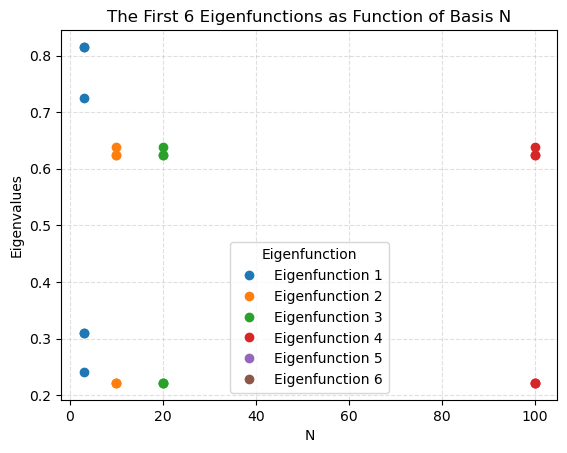

In [ ]:
plt.plot(n[0]*np.ones(6),eiglist[0],'o')
plt.plot(n[1]*np.ones(6),eiglist[1],'o')
plt.plot(n[2]*np.ones(6),eiglist[2],'o')
plt.plot(n[3]*np.ones(6),eiglist[3],'o')
plt.xlabel("N")              
plt.ylabel("Eigenvalues")       
plt.title("The First 6 Eigenfunctions as Function of Basis N")
plt.grid(True, linestyle="--", alpha=0.4)

# Below is code for the legend 
from matplotlib.lines import Line2D
plt.legend(handles=[Line2D([0],[0], marker='o', linestyle='',
                           color=plt.get_cmap('tab10').colors[k],
                           label=f"Eigenfunction {k+1}") for k in range(6)],
           title="Eigenfunction") 

plt.show()

(b) Prepare a two-slides presentation identifying the main features of this system.
The slides must include a plot of the potential superposed to the energy levels you found, as well as
a plot of the first six eigenfunctions.

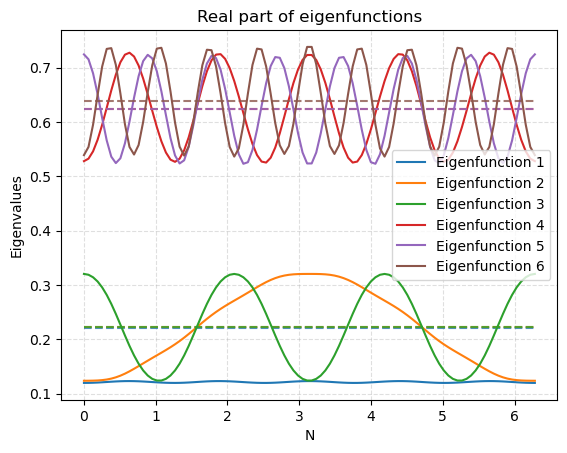

In [85]:
# pick distinct colors for k = 0.5
cmap = plt.get_cmap('tab10')

points = 100
thetaList = np.linspace(0,2*np.pi,points)
potE = V0*np.sin((3*thetaList/2))**2

fList = []

for j in range(0,6):
    color = cmap(j)  # <-- same color for eigenvalue j and eigenfunction j
    fn = 0
    for n in range (-points,points+1):
        indNv = n + points 
        fn = fn + HvecsSort[j,indNv]*np.exp(1j*thetaList*n)/np.sqrt(2*np.pi) 
    
    fn = fn/np.sqrt(np.vdot(fn,fn))
    fList.append(fn)

    # dashed eigenvalue line, colored by j
    plt.plot(thetaList, eiglist[3][j]*np.ones(points),
             linestyle='--', color=color, alpha=0.8)

    # eigenfunction (real part) offset by its eigenvalue, same color
    plt.plot(thetaList, np.real(fn) + eiglist[3][j],
             color=color, label=f"Eigenfunction {j+1}")

plt.title('Real part of eigenfunctions')
plt.xlabel("N")              
plt.ylabel("Eigenvalues")       
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()
